# Google Colab only

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ln -sf '/content/drive/MyDrive/cnn-baseline' '/content/cnn-baseline'

Mounted at /content/drive


In [2]:
!pip install tf_keras --quiet && echo "tf_keras installed"

tf_keras installed


In [3]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tf_keras.api._v2.keras as keras

print(tf.keras)
print(keras)

if "v2" not in tf.keras.__file__ and "v2" not in keras.__file__:
  raise Exception("Must use legavy Keras v2")
else:
  print("Legacy keras activated")

<KerasLazyLoader>
<module 'tf_keras.api._v2.keras' from '/usr/local/lib/python3.12/dist-packages/tf_keras/api/_v2/keras/__init__.py'>
Legacy keras activated


# Define constants

In [15]:
CLEAN_FEATURES_PATH = "./cnn-baseline/opus-training.npz"
NOISY_FEATURES_PATH = "./cnn-baseline/opus-evaluation.npz"
MODEL_SAVE_PATH = "./model-bn-c64-c128-c256-c256-d256"
RANDOM_STATE = 42
CNN_VALIDATION_SPLIT = 0.1
CNN_TEST_SIZE = 0.1
CNN_EPOCHS = 50
CNN_BATCH_SIZE = 32
CNN_LEARNING_RATE  = 0.001

KFOLD_N_SPLITS = 5
KFOLD_VALIDATION_SPLIT = CNN_VALIDATION_SPLIT
KFOLD_TEST_SIZE = CNN_TEST_SIZE
KFOLD_EPOCHS = CNN_EPOCHS
KFOLD_BATCH_SIZE = CNN_BATCH_SIZE

SKFOLD_N_SPLITS = KFOLD_N_SPLITS
SKFOLD_VALIDATION_SPLIT = CNN_VALIDATION_SPLIT
SKFOLD_TEST_SIZE = CNN_TEST_SIZE
SKFOLD_EPOCHS = CNN_EPOCHS
SKFOLD_BATCH_SIZE = CNN_BATCH_SIZE

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
import random
import numpy as np
import tensorflow as tf

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
  tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [16]:
from tensorflow.keras import Input, layers, models, callbacks

def build_model(input_shape, num_classes):
  model = models.Sequential([
    Input(shape=input_shape),

    # Batch normalization on frequency axis
    layers.BatchNormalization(axis=1),

    # Conv block 1
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Conv block 2
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Conv block 3
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # # Conv block 4
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    # Dense head
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
  ])

  model.compile(optimizer=optimizers.Adam(learning_rate=CNN_LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

  return model

def get_callbacks():
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.1,
        patience=2,
        verbose=1
    )
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
    return [reduce_lr, early_stop]

# Training

### Load features

In [6]:
data = np.load(CLEAN_FEATURES_PATH)
features = data['features']
labels = data['labels']

### Split data


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    features,
    categorical_labels,
    test_size=CNN_TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=categorical_labels
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Length of training set: {len(X_train)}")
print(f"Length of testing set: {len(X_test)}")

Shape of X_train: (6480, 216, 188)
Shape of X_test: (720, 216, 188)
Shape of y_train: (6480, 36)
Shape of y_test: (720, 36)
Length of training set: 6480
Length of testing set: 720


### Build model


In [14]:
from tensorflow.keras import optimizers

# Get input shape and number of classes
input_shape = (features.shape[1], features.shape[2], 1) # Add channel dimension based on original features shape
num_classes = y_train.shape[1]

# Build the CNN model
model = build_model(input_shape, num_classes)

model.summary()

NameError: name 'build_model' is not defined

### Train model

In [ ]:
history = model.fit(X_train, y_train, epochs=CNN_EPOCHS, batch_size=CNN_BATCH_SIZE, validation_split=CNN_VALIDATION_SPLIT, callbacks=get_callbacks())

Epoch 1/50
183/183 [==============================] - 23s 92ms/step - loss: 0.8941 - accuracy: 0.7488 - val_loss: 0.0360 - val_accuracy: 0.9907 - lr: 0.0010
Epoch 2/50
183/183 [==============================] - 16s 89ms/step - loss: 0.0439 - accuracy: 0.9880 - val_loss: 0.0273 - val_accuracy: 0.9985 - lr: 0.0010
Epoch 3/50
183/183 [==============================] - 16s 90ms/step - loss: 0.0414 - accuracy: 0.9901 - val_loss: 0.0268 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 4/50
183/183 [==============================] - 17s 93ms/step - loss: 0.0083 - accuracy: 0.9978 - val_loss: 0.0263 - val_accuracy: 0.9985 - lr: 0.0010
Epoch 5/50
183/183 [==============================] - 17s 94ms/step - loss: 0.0246 - accuracy: 0.9940 - val_loss: 0.0232 - val_accuracy: 0.9985 - lr: 0.0010
Epoch 6/50
183/183 [==============================] - 17s 95ms/step - loss: 0.0123 - accuracy: 0.9974 - val_loss: 6.7054e-07 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 7/50
183/183 [==============================] - 

### Class distribution

In [ ]:
from collections import Counter
import numpy as np

import matplotlib.pyplot as plt

# Keras validation_split takes the last fraction of training data
val_size = int(len(y_train) * CNN_VALIDATION_SPLIT)
y_train_actual = y_train[:-val_size]
y_val          = y_train[-val_size:]

# Get class distribution for train, validation, and test sets
train_dist = Counter(np.argmax(y_train_actual, axis=1))
val_dist   = Counter(np.argmax(y_val,          axis=1))
test_dist  = Counter(np.argmax(y_test,         axis=1))

class_names = label_encoder.classes_
x = np.arange(len(class_names))
width = 0.4

train_counts = [train_dist.get(i, 0) for i in range(len(class_names))]
val_counts   = [val_dist.get(i, 0)   for i in range(len(class_names))]
test_counts  = [test_dist.get(i, 0)  for i in range(len(class_names))]

# Print summary table
print(f"\n{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 56)
for i, name in enumerate(class_names):
  tr = train_dist.get(i, 0)
  vl = val_dist.get(i, 0)
  te = test_dist.get(i, 0)
  print(f"{name:<20} {tr:>8} {vl:>8} {te:>8} {tr+vl+te:>8}")
print("-" * 56)
print(f"{'TOTAL':<20} {sum(train_counts):>8} {sum(val_counts):>8} {sum(test_counts):>8} {sum(train_counts)+sum(val_counts)+sum(test_counts):>8}")



Class                   Train      Val     Test    Total
--------------------------------------------------------
A#_diminished_4           166       14       20      200
A#_major_4                167       13       20      200
A#_minor_4                162       18       20      200
A_diminished_4            166       14       20      200
A_major_4                 155       25       20      200
A_minor_4                 160       20       20      200
B_diminished_4            160       20       20      200
B_major_4                 162       18       20      200
B_minor_4                 164       16       20      200
C#_diminished_4           165       15       20      200
C#_major_4                168       12       20      200
C#_minor_4                166       14       20      200
C_diminished_4            157       23       20      200
C_major_4                 156       24       20      200
C_minor_4                 158       22       20      200
D#_diminished_4           162 

### Training history

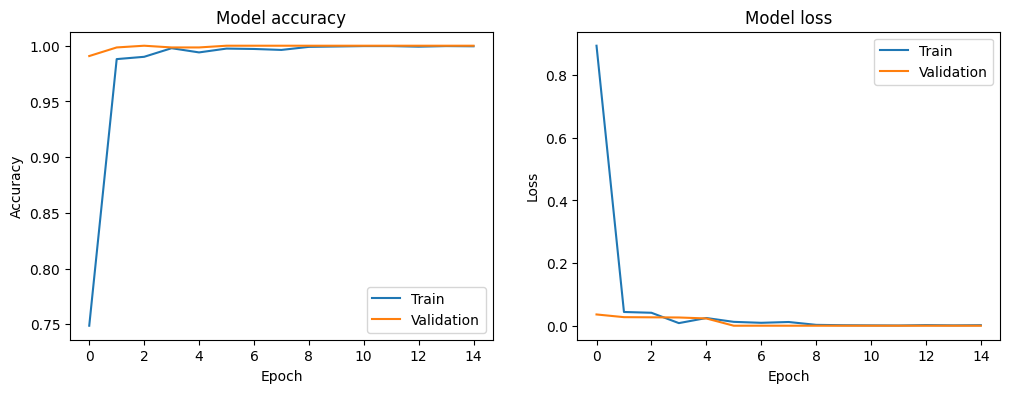

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.show()

### Confusion Matrix

23/23 [==============================] - 1s 24ms/step


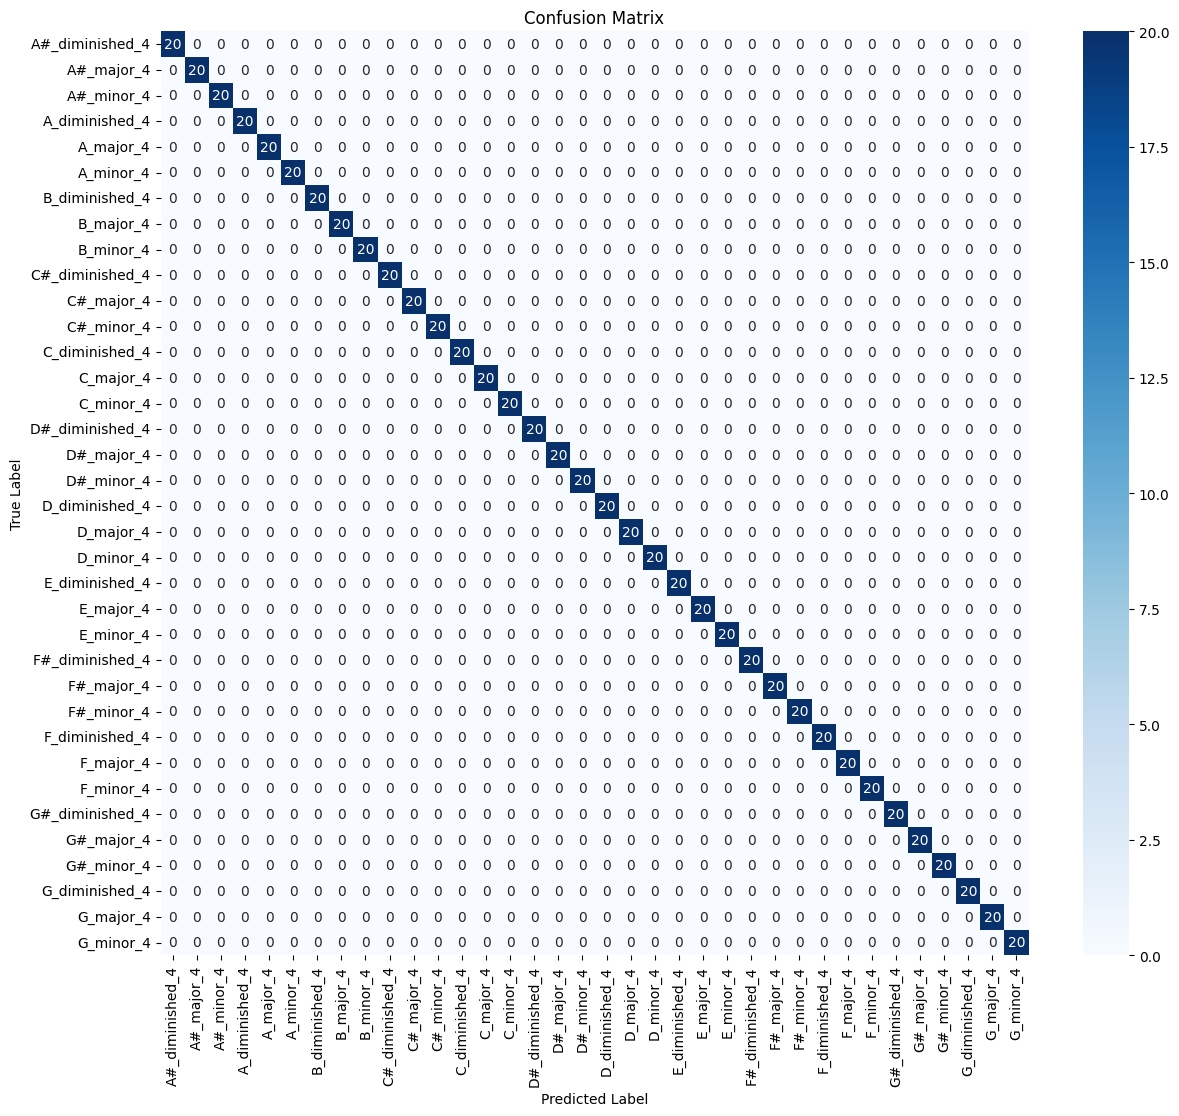

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Get class labels from the label encoder
class_labels = label_encoder.classes_

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy}")
print(f"Test Loss: {loss}")

# Generate classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels)
print("Classification Report:\n", report)

Test Accuracy: 1.0
Test Loss: 1.6060109686577562e-08
Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00        20
     A#_major_4       1.00      1.00      1.00        20
     A#_minor_4       1.00      1.00      1.00        20
 A_diminished_4       1.00      1.00      1.00        20
      A_major_4       1.00      1.00      1.00        20
      A_minor_4       1.00      1.00      1.00        20
 B_diminished_4       1.00      1.00      1.00        20
      B_major_4       1.00      1.00      1.00        20
      B_minor_4       1.00      1.00      1.00        20
C#_diminished_4       1.00      1.00      1.00        20
     C#_major_4       1.00      1.00      1.00        20
     C#_minor_4       1.00      1.00      1.00        20
 C_diminished_4       1.00      1.00      1.00        20
      C_major_4       1.00      1.00      1.00        20
      C_minor_4       1.00      1.00      1.00        20
D#_diminis

### Save Model

In [ ]:
import gc

# Save the model
model.save(MODEL_SAVE_PATH + '.h5')
model.save(MODEL_SAVE_PATH + '.keras')
print(f"Model saved to {MODEL_SAVE_PATH}")

# Clear memory
tf.keras.backend.clear_session()
del model
gc.collect()

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved to ./model-bn-c64-c128-c256-c256-d256


### Convert model to tfjs

In [ ]:
!TF_DETERMINISTIC_OPS=0 tensorflowjs_converter --input_format=keras --output_format=tfjs_graph_model {MODEL_SAVE_PATH}.h5 {MODEL_SAVE_PATH} && echo TensorFlow.js model saved to {MODEL_SAVE_PATH}

/bin/bash: line 1: tensorflowjs_converter: command not found


# Cross Validation

## K-Fold cross-validation

### Define constants

In [17]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)

input_shape = (features.shape[1], features.shape[2], 1)
num_classes = categorical_labels.shape[1]

### Train

In [18]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import tensorflow as tf
import gc

# Instantiate KFold
kf = KFold(n_splits=KFOLD_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Initialize lists to store performance metrics for each fold
fold_accuracies = []
fold_losses = []
fold_histories = []
fold_confusion_matrices = []

for fold, (train_val_index, test_index) in enumerate(kf.split(features, encoded_labels)):
    print(f"\n--- Fold {fold+1}/{kf.n_splits} ---")

    # Set per-fold seed so each fold is independently reproducible
    tf.random.set_seed(RANDOM_STATE + fold)
    np.random.seed(RANDOM_STATE + fold)

    # Split train_val_index
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=KFOLD_TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=encoded_labels[train_val_index]  # preserve class distribution
    )

    X_train_fold = np.expand_dims(features[train_index], axis=-1)
    X_val_fold   = np.expand_dims(features[val_index],   axis=-1)
    X_test_fold  = np.expand_dims(features[test_index],  axis=-1)

    y_train_fold = categorical_labels[train_index]
    y_val_fold   = categorical_labels[val_index]
    y_test_fold  = categorical_labels[test_index]

    model = build_model(input_shape, num_classes)

    print(f"Training model for Fold {fold+1}...")
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=KFOLD_EPOCHS,
        batch_size=KFOLD_BATCH_SIZE,
        validation_data=(X_val_fold, y_val_fold),  # enables val metrics per epoch
        validation_split=KFOLD_VALIDATION_SPLIT,
        callbacks=get_callbacks(),
    )
    fold_histories.append(history)

    print(f"Evaluating model for Fold {fold+1}...")
    loss, accuracy = model.evaluate(X_test_fold, y_test_fold, verbose=0)

    y_pred_fold = model.predict(X_test_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred_fold, axis=1)
    y_true_classes = np.argmax(y_test_fold, axis=1)
    fold_confusion_matrices.append(confusion_matrix(y_true_classes, y_pred_classes))

    fold_accuracies.append(accuracy)
    fold_losses.append(loss)

    tf.keras.backend.clear_session()
    del model
    gc.collect()
    print(f"Fold {fold+1} - Test Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")

print("\nK-Fold Cross-Validation complete.")



--- Fold 1/5 ---
Training model for Fold 1...
Epoch 1/50
162/162 [==============================] - 21s 93ms/step - loss: 1.0041 - accuracy: 0.7205 - val_loss: 0.0193 - val_accuracy: 0.9948 - lr: 0.0010
Epoch 2/50
162/162 [==============================] - 15s 91ms/step - loss: 0.0509 - accuracy: 0.9877 - val_loss: 0.0176 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 3/50
162/162 [==============================] - 15s 94ms/step - loss: 0.0343 - accuracy: 0.9934 - val_loss: 0.0175 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 4/50
162/162 [==============================] - 16s 100ms/step - loss: 0.0156 - accuracy: 0.9969 - val_loss: 1.0974e-05 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 5/50
162/162 [==============================] - 15s 93ms/step - loss: 0.0072 - accuracy: 0.9977 - val_loss: 7.8048e-05 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 6/50
162/162 [==============================] - ETA: 0s - loss: 0.0232 - accuracy: 0.9950
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00010000

### Show class distribution

In [19]:
from collections import Counter
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

for fold, (train_val_index, test_index) in enumerate(kf.split(features, encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=KFOLD_TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=encoded_labels[train_val_index]
    )

    train_dist = Counter(encoded_labels[train_index])
    val_dist   = Counter(encoded_labels[val_index])
    test_dist  = Counter(encoded_labels[test_index])

    classes = sorted(train_dist.keys())
    class_names = label_encoder.inverse_transform(classes)

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(classes, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} {sum(test_dist.values()):>8}  {len(encoded_labels):>8}")

print("\n" + "=" * 65)

              Class Distribution per Fold

  Fold 1
  Class                   Train      Val     Test     Total
  -------------------- -------- -------- --------  --------
  A#_diminished_4           142       16       42       200
  A#_major_4                141       16       43       200
  A#_minor_4                134       15       51       200
  A_diminished_4            149       16       35       200
  A_major_4                 156       17       27       200
  A_minor_4                 134       15       51       200
  B_diminished_4            149       16       35       200
  B_major_4                 134       15       51       200
  B_minor_4                 140       15       45       200
  C#_diminished_4           149       17       34       200
  C#_major_4                150       17       33       200
  C#_minor_4                144       16       40       200
  C_diminished_4            141       16       43       200
  C_major_4                 146       16       3

### Confusion Matrix per Fold

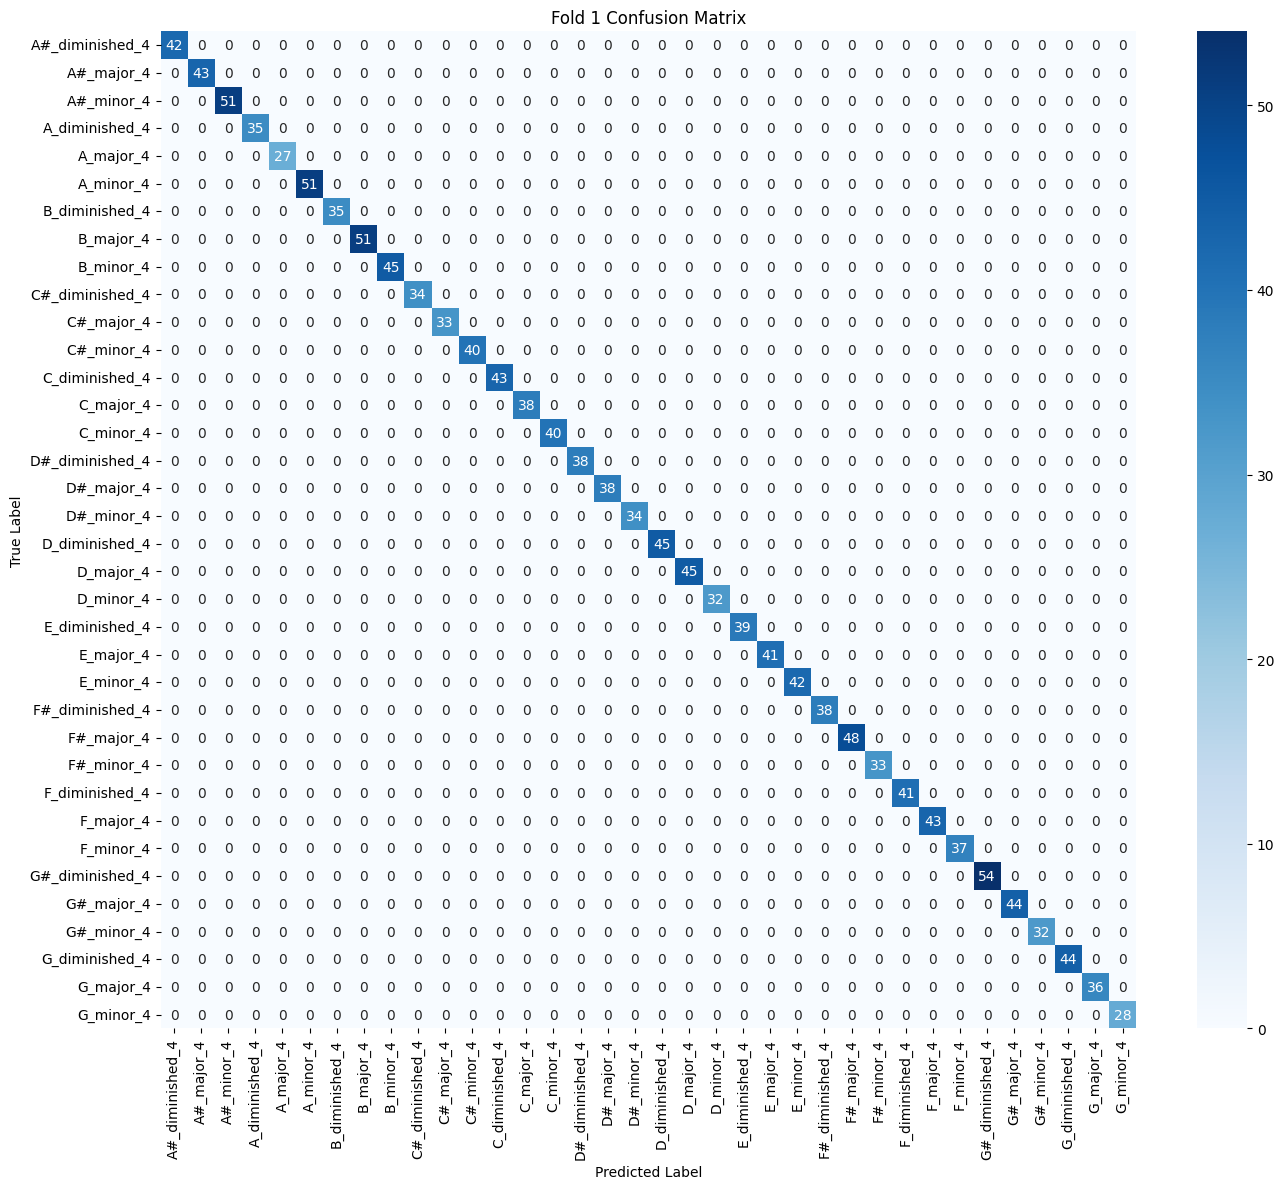

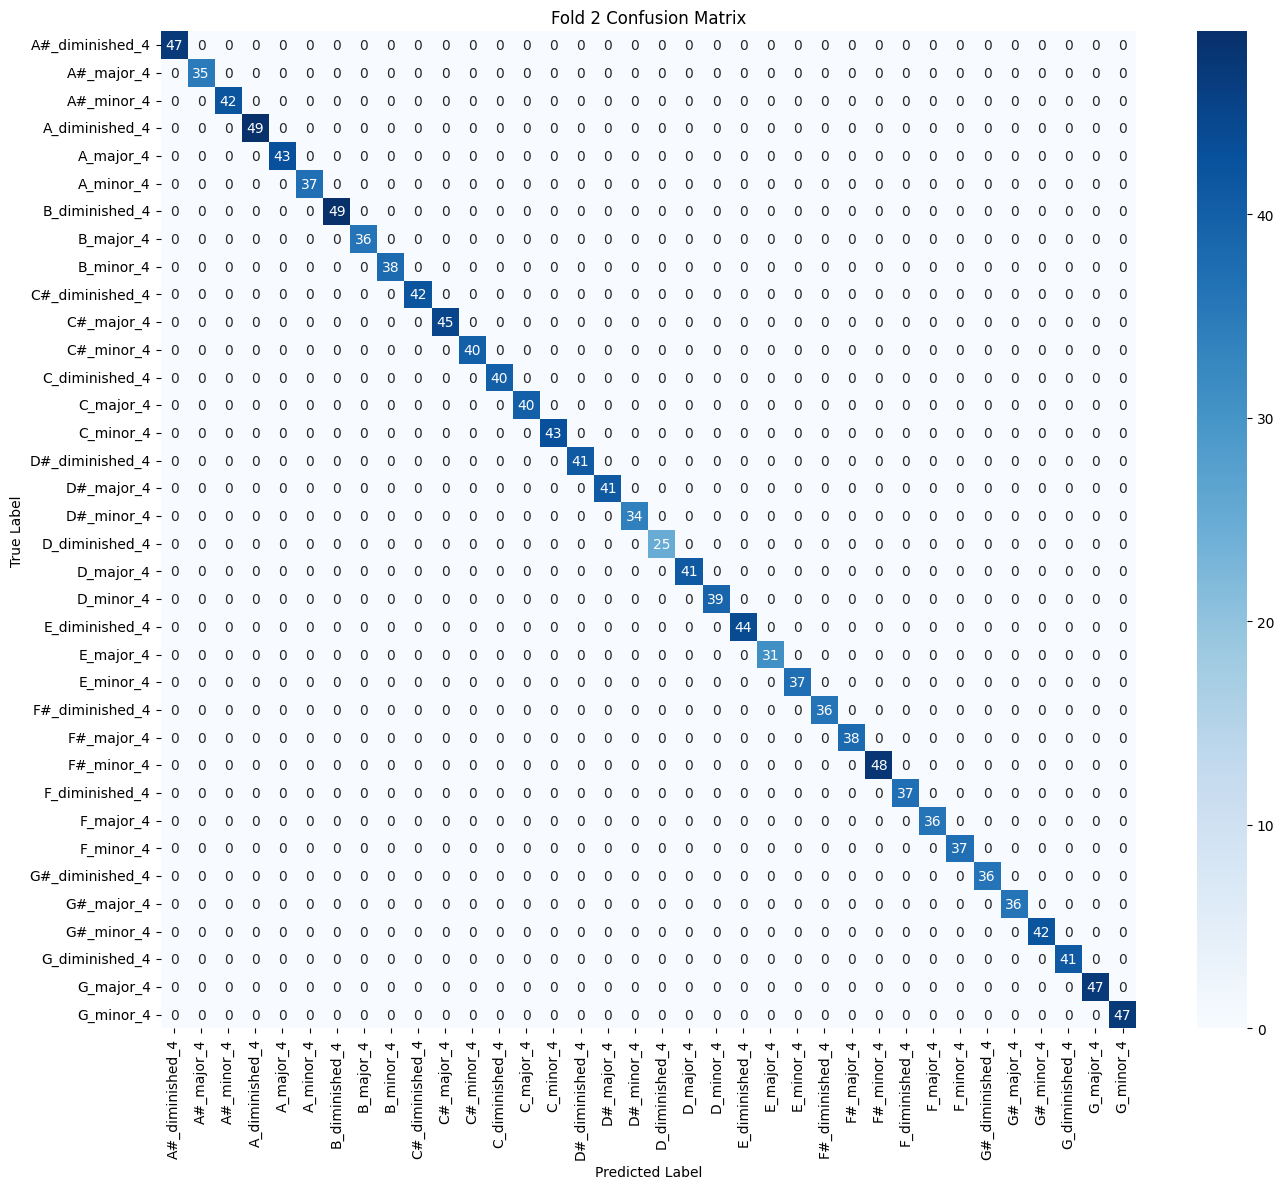

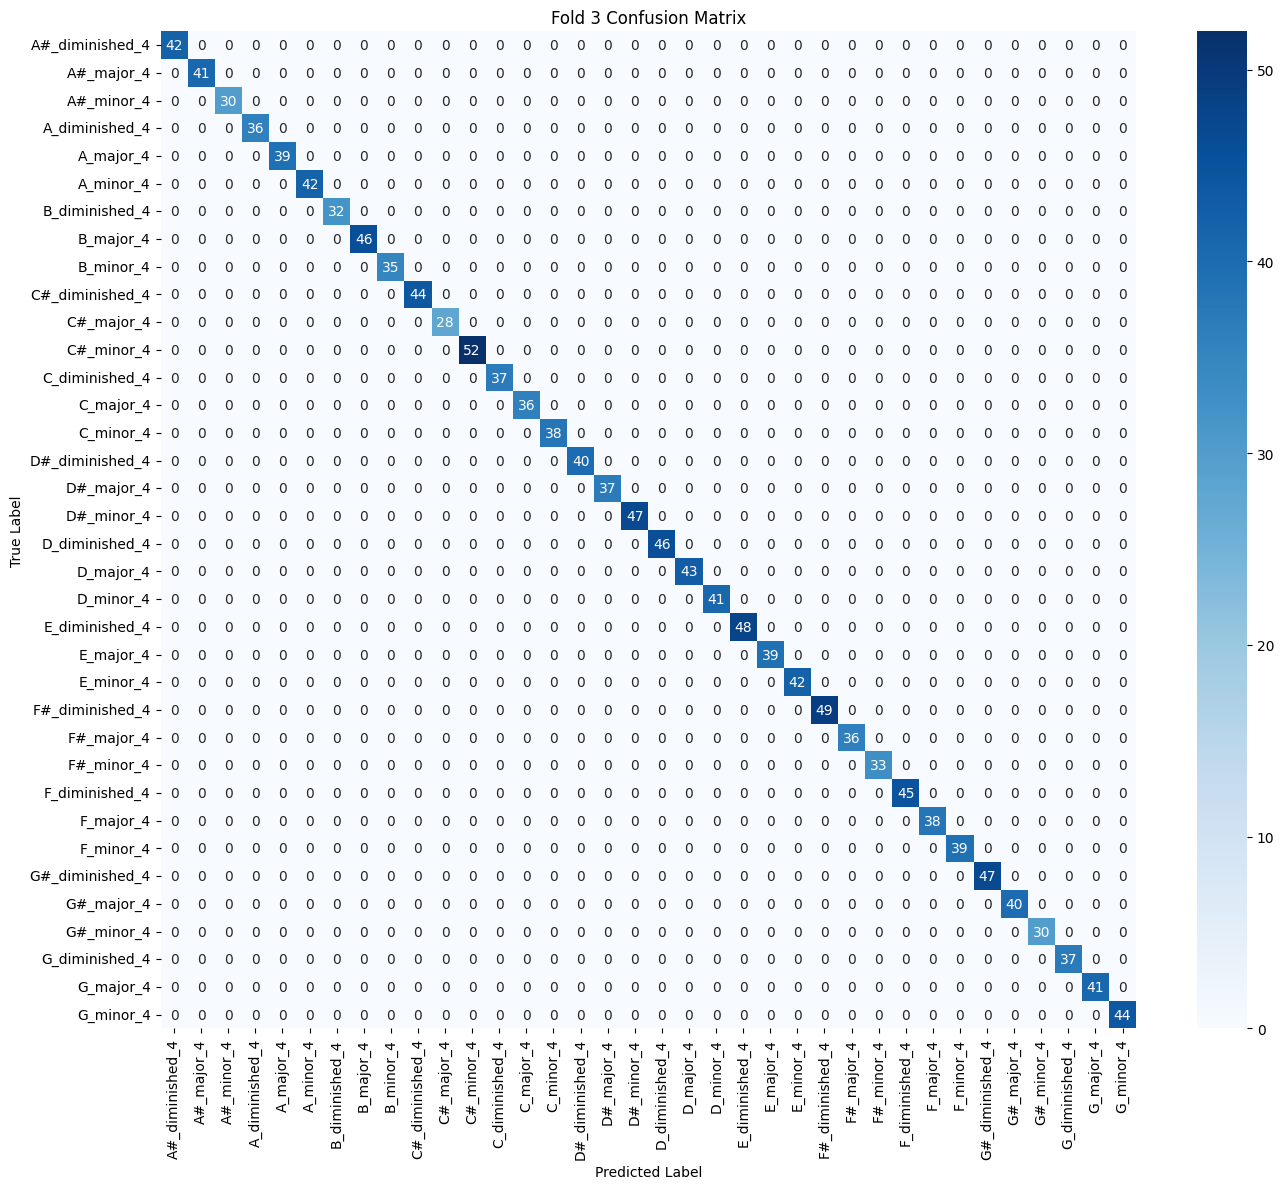

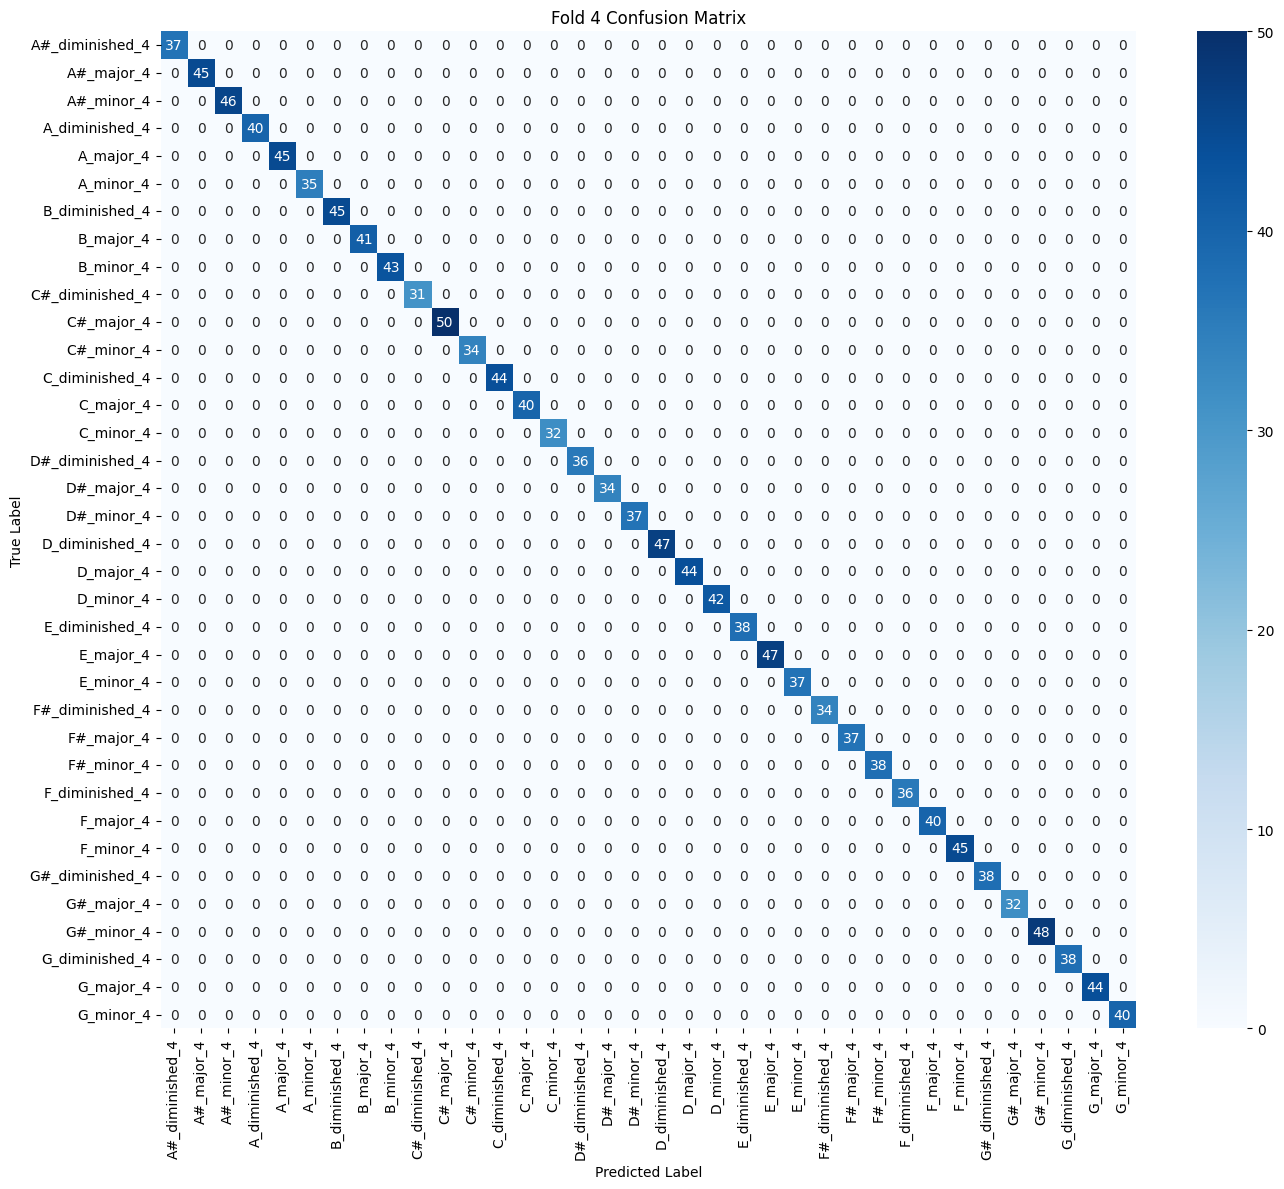

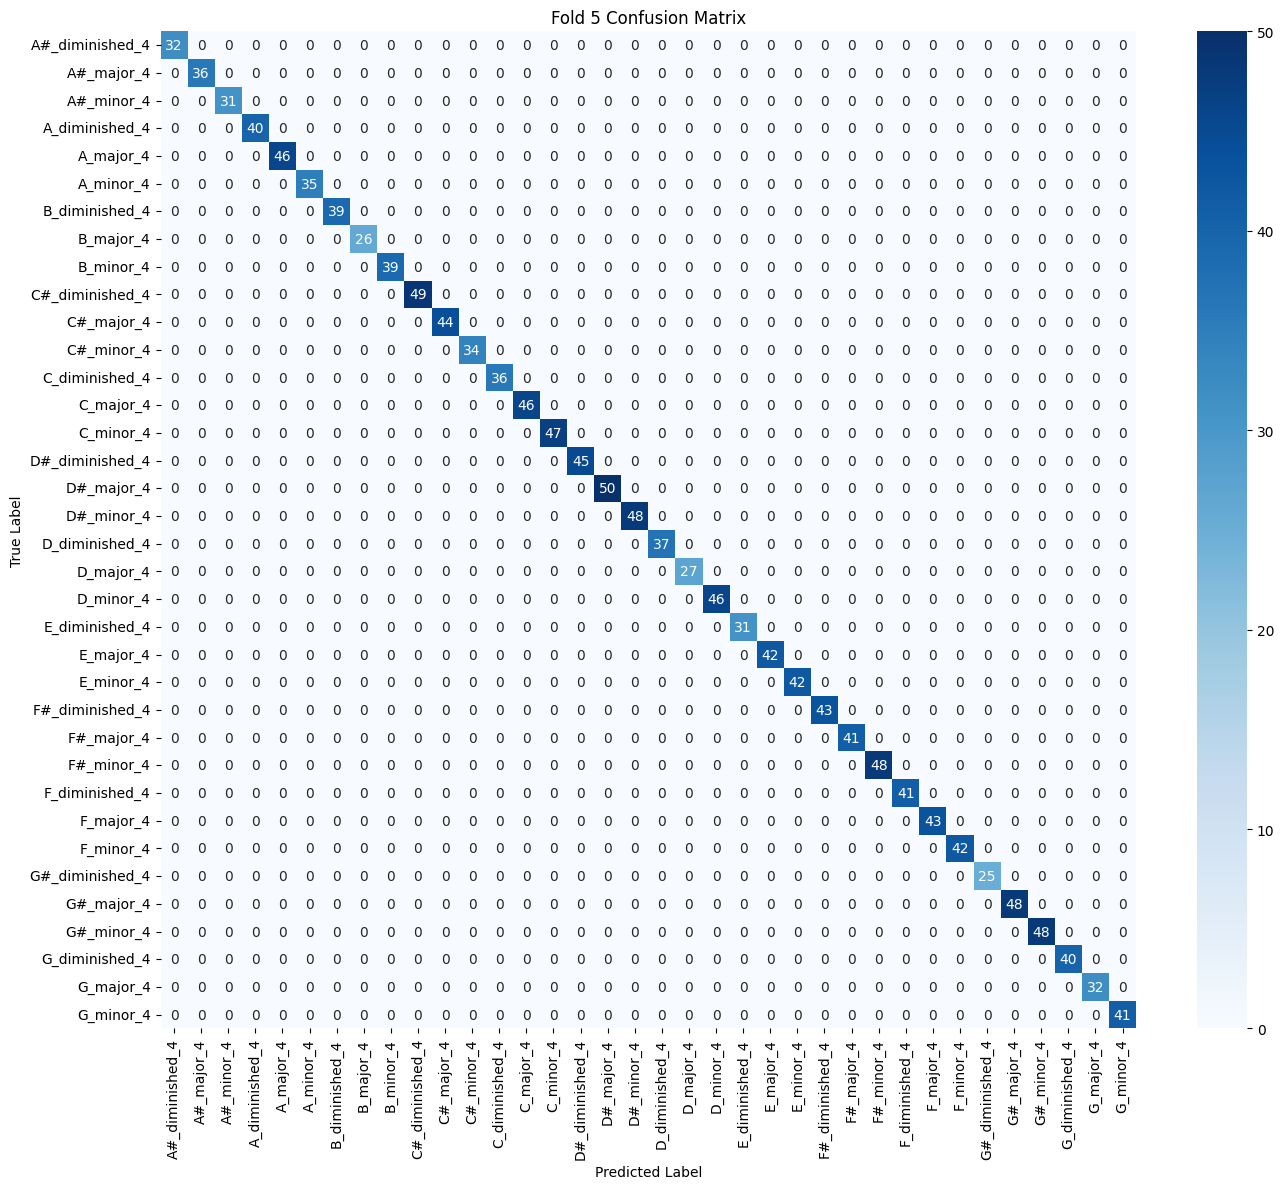

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

class_labels = label_encoder.classes_

for i, cm in enumerate(fold_confusion_matrices):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Fold {i+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

### Accuracy & Loss Plot

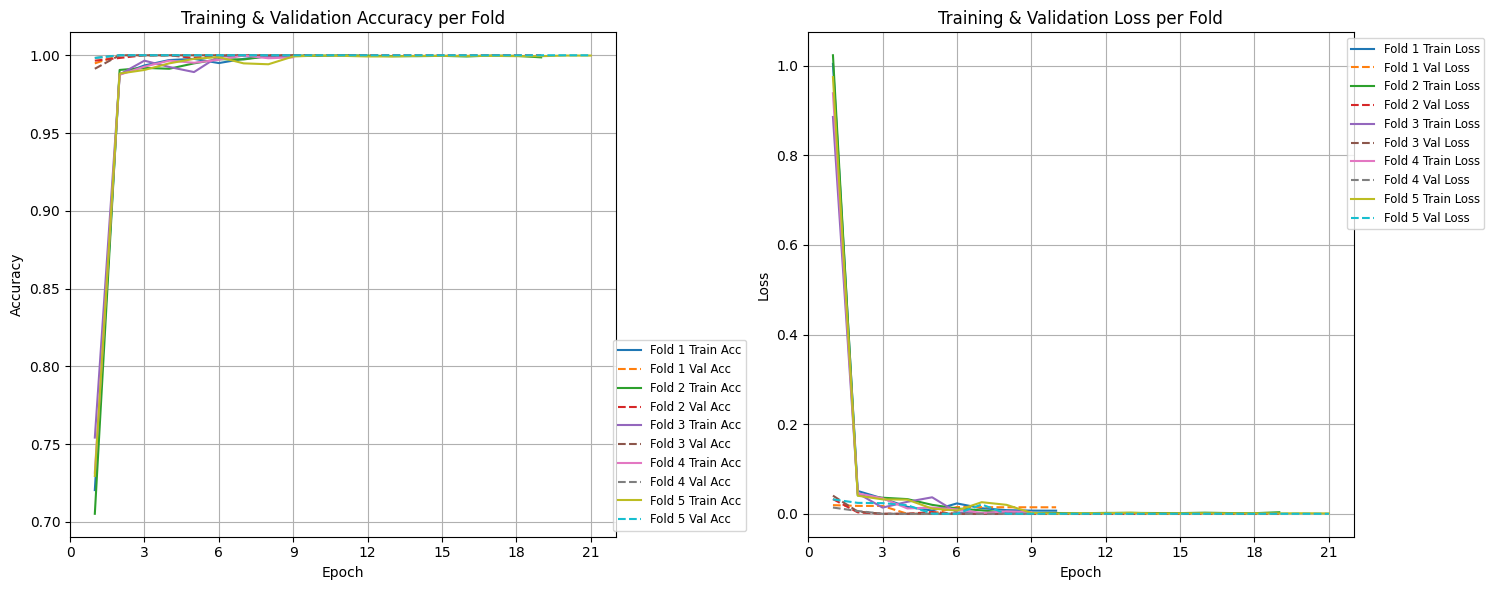

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(15, 6))

# --- Accuracy ---
ax1 = plt.subplot(1, 2, 1)
for i, history_obj in enumerate(fold_histories):
    epochs = range(1, len(history_obj.history['accuracy']) + 1)
    plt.plot(epochs, history_obj.history['accuracy'],
             label=f'Fold {i+1} Train Acc')
    plt.plot(epochs, history_obj.history['val_accuracy'],
             linestyle='--', label=f'Fold {i+1} Val Acc')

plt.title('Training & Validation Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend(loc='lower right', bbox_to_anchor=(1.25, 0), fontsize='small')
plt.grid(True)

# --- Loss ---
ax2 = plt.subplot(1, 2, 2)
for i, history_obj in enumerate(fold_histories):
    epochs = range(1, len(history_obj.history['loss']) + 1)
    plt.plot(epochs, history_obj.history['loss'],
             label=f'Fold {i+1} Train Loss')
    plt.plot(epochs, history_obj.history['val_loss'],
             linestyle='--', label=f'Fold {i+1} Val Loss')

plt.title('Training & Validation Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()

### Mean & Std Deviation

In [22]:
import numpy as np

# Collect final-epoch train/val metrics from each fold's history
train_accs = [h.history['accuracy'][-1]     for h in fold_histories]
val_accs   = [h.history['val_accuracy'][-1] for h in fold_histories]
train_losses = [h.history['loss'][-1]       for h in fold_histories]
val_losses   = [h.history['val_loss'][-1]   for h in fold_histories]

print("=" * 73)
print("         Stratified K-Fold Cross-Validation Summary (per fold)")
print("=" * 73)
print(f"  {'':>6}  {'Train Acc':>10}  {'Val Acc':>10}  {'Test Acc':>10}  {'Train Loss':>11}  {'Val Loss':>10}  {'Test Loss':>10}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
for i in range(len(fold_accuracies)):
    print(f"  Fold {i+1:>1}  {train_accs[i]:>10.4f}  {val_accs[i]:>10.4f}  {fold_accuracies[i]:>10.4f}  {train_losses[i]:>11.4f}  {val_losses[i]:>10.4f}  {fold_losses[i]:>10.4f}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
print(f"  {'Mean':>6}  {np.mean(train_accs):>10.4f}  {np.mean(val_accs):>10.4f}  {np.mean(fold_accuracies):>10.4f}  {np.mean(train_losses):>11.4f}  {np.mean(val_losses):>10.4f}  {np.mean(fold_losses):>10.4f}")
print(f"  {'Std':>6}  {np.std(train_accs):>10.4f}  {np.std(val_accs):>10.4f}  {np.std(fold_accuracies):>10.4f}  {np.std(train_losses):>11.4f}  {np.std(val_losses):>10.4f}  {np.std(fold_losses):>10.4f}")
print("=" * 73)

         Stratified K-Fold Cross-Validation Summary (per fold)
           Train Acc     Val Acc    Test Acc   Train Loss    Val Loss   Test Loss
  ------  ----------  ----------  ----------  -----------  ----------  ----------
  Fold 1      0.9998      1.0000      1.0000       0.0069      0.0145      0.0000
  Fold 2      0.9986      1.0000      1.0000       0.0035      0.0000      0.0001
  Fold 3      0.9994      1.0000      1.0000       0.0022      0.0000      0.0000
  Fold 4      0.9986      1.0000      1.0000       0.0038      0.0000      0.0000
  Fold 5      0.9998      1.0000      1.0000       0.0008      0.0000      0.0000
  ------  ----------  ----------  ----------  -----------  ----------  ----------
    Mean      0.9993      1.0000      1.0000       0.0034      0.0029      0.0000
     Std      0.0005      0.0000      0.0000       0.0020      0.0058      0.0000


### Per Class Accuracies

Per-Class Accuracy (Mean ± Std across folds)
              Class  Mean Acc  Std Acc
1   A#_diminished_4       1.0      0.0
2        A#_major_4       1.0      0.0
3        A#_minor_4       1.0      0.0
4    A_diminished_4       1.0      0.0
5         A_major_4       1.0      0.0
6         A_minor_4       1.0      0.0
7    B_diminished_4       1.0      0.0
8         B_major_4       1.0      0.0
9         B_minor_4       1.0      0.0
10  C#_diminished_4       1.0      0.0
11       C#_major_4       1.0      0.0
12       C#_minor_4       1.0      0.0
13   C_diminished_4       1.0      0.0
14        C_major_4       1.0      0.0
15        C_minor_4       1.0      0.0
16  D#_diminished_4       1.0      0.0
17       D#_major_4       1.0      0.0
18       D#_minor_4       1.0      0.0
19   D_diminished_4       1.0      0.0
20        D_major_4       1.0      0.0
21        D_minor_4       1.0      0.0
22   E_diminished_4       1.0      0.0
23        E_major_4       1.0      0.0
24        E_minor_4

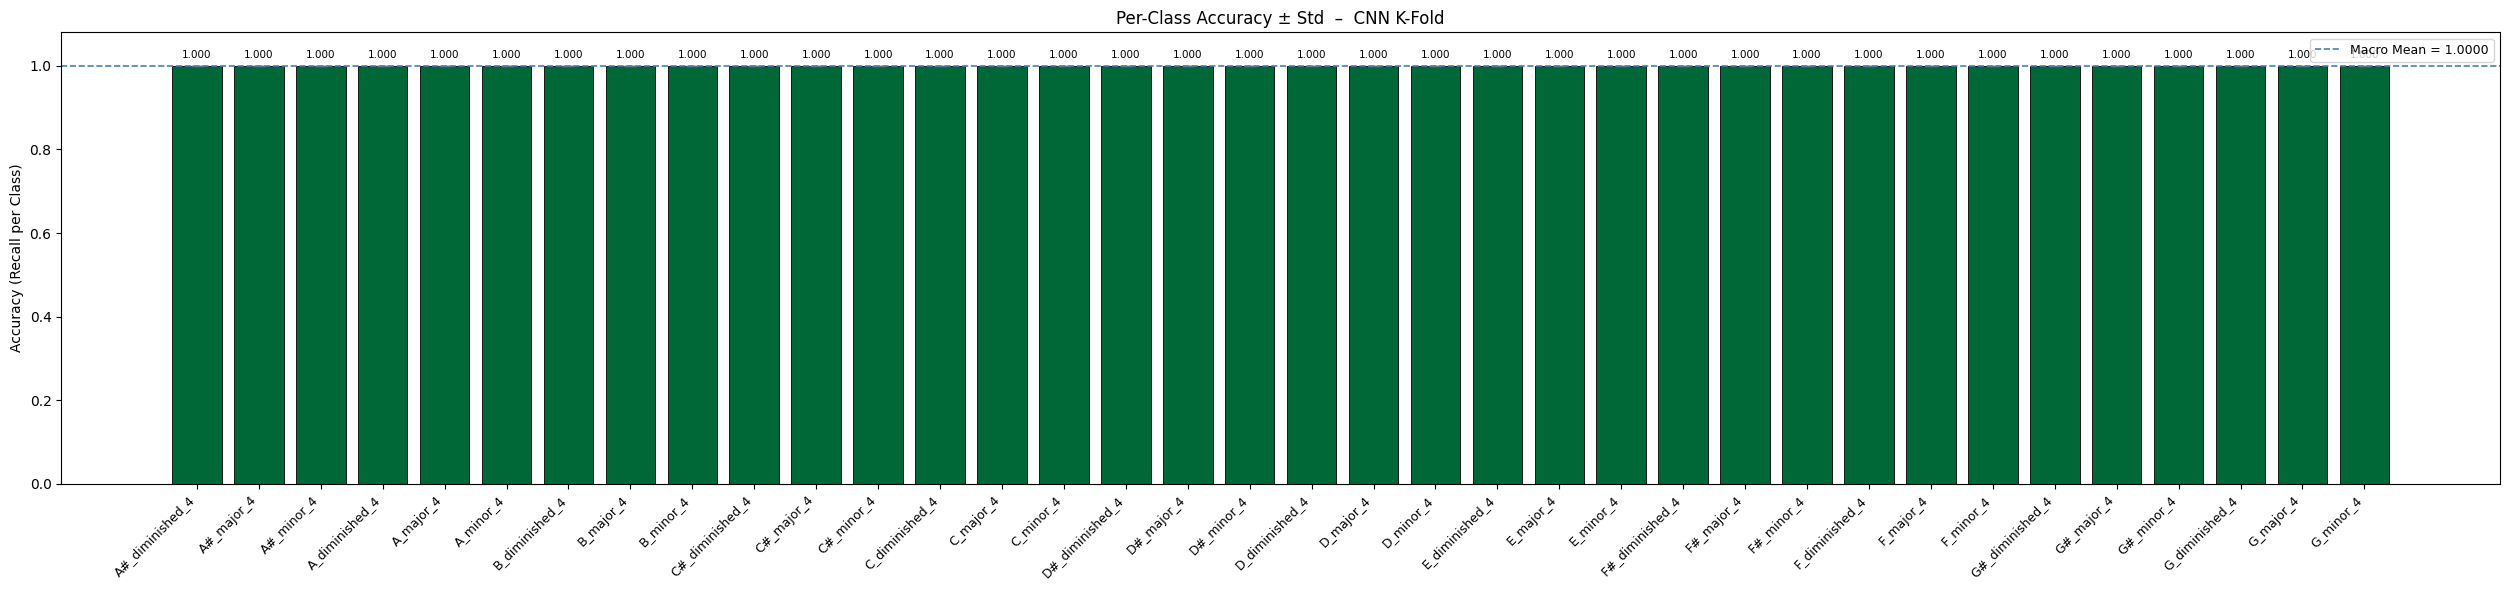

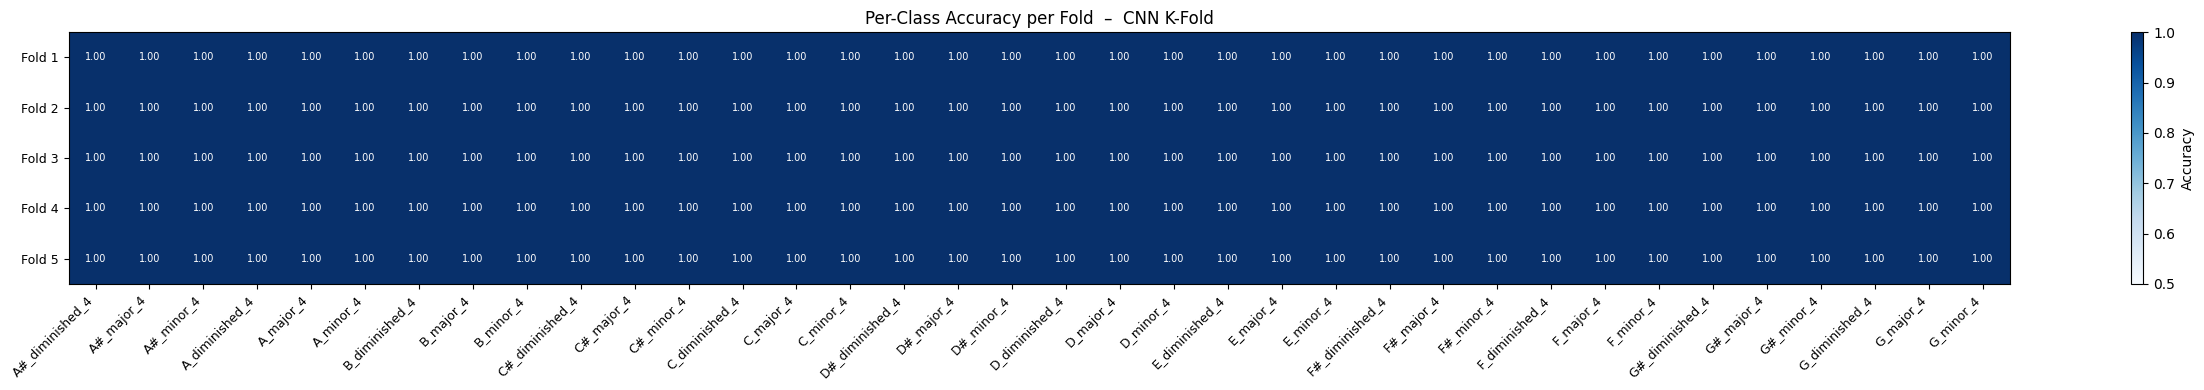

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Extract per-class accuracy for every fold ──────────────────────────────
class_names = label_encoder.classes_          # shape: (n_classes,)
n_folds     = len(fold_confusion_matrices)
n_classes   = len(class_names)

# per_class_acc[fold, class] = recall of that class in that fold
per_class_acc = np.zeros((n_folds, n_classes))

for fold_idx, cm in enumerate(fold_confusion_matrices):
    row_sums = cm.sum(axis=1)                     # true counts per class
    with np.errstate(divide='ignore', invalid='ignore'):
        acc = np.where(row_sums > 0, cm.diagonal() / row_sums, np.nan)
    per_class_acc[fold_idx] = acc

# ── 2. Mean & Std across folds ────────────────────────────────────────────────
mean_acc = np.nanmean(per_class_acc, axis=0)
std_acc  = np.nanstd(per_class_acc,  axis=0)

# ── 3. Build summary DataFrame ────────────────────────────────────────────────
df_class_acc = pd.DataFrame({
    "Class":    class_names,
    "Mean Acc": mean_acc,
    "Std Acc":  std_acc,
})
df_class_acc = df_class_acc.sort_values("Mean Acc", ascending=False).reset_index(drop=True)
df_class_acc.index += 1                           # rank starts at 1

print("Per-Class Accuracy (Mean ± Std across folds)")
print("=" * 45)
print(df_class_acc.to_string())

# ── 4. Bar chart with error bars ──────────────────────────────────────────────
sorted_classes = df_class_acc["Class"].values
sorted_mean    = df_class_acc["Mean Acc"].values
sorted_std     = df_class_acc["Std Acc"].values

colors = plt.cm.RdYlGn(sorted_mean)              # red=low, green=high

fig, ax = plt.subplots(figsize=(max(10, n_classes * 0.7), 6))
bars = ax.bar(
    range(n_classes), sorted_mean,
    yerr=sorted_std, capsize=4,
    color=colors, edgecolor="black", linewidth=0.6,
    error_kw={"elinewidth": 1.2, "ecolor": "dimgray"}
)

ax.set_xticks(range(n_classes))
ax.set_xticklabels(sorted_classes, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (Recall per Class)")
ax.set_title("Per-Class Accuracy ± Std  –  CNN K-Fold")
ax.set_ylim(0, 1.08)
ax.axhline(y=sorted_mean.mean(), color="steelblue",
           linestyle="--", linewidth=1.2, label=f"Macro Mean = {sorted_mean.mean():.4f}")
ax.legend(fontsize=9)

for i, (m, s) in enumerate(zip(sorted_mean, sorted_std)):
    ax.text(i, m + s + 0.015, f"{m:.3f}", ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.show()

# ── 5. Optional: per-fold heatmap ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(max(10, n_classes * 0.7), max(4, n_folds * 0.55)))
im = ax2.imshow(per_class_acc, aspect="auto", cmap="Blues", vmin=0.5, vmax=1)

ax2.set_xticks(range(n_classes))
ax2.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
ax2.set_yticks(range(n_folds))
ax2.set_yticklabels([f"Fold {i+1}" for i in range(n_folds)], fontsize=9)
ax2.set_title("Per-Class Accuracy per Fold  –  CNN K-Fold")
fig2.colorbar(im, ax=ax2, label="Accuracy")

for fold_i in range(n_folds):
    for cls_j in range(n_classes):
        val = per_class_acc[fold_i, cls_j]
        ax2.text(cls_j, fold_i, f"{val:.2f}", ha="center", va="center",
                 fontsize=7, color="black" if 0.35 < val < 0.85 else "white")

plt.tight_layout()
plt.show()

## Stratified K-Fold

### Train

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf

# Instantiate KFold
skf = StratifiedKFold(n_splits=SKFOLD_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Initialize lists to store performance metrics for each fold
sfold_accuracies = []
sfold_losses = []
sfold_histories = []
sfold_confusion_matrices = []

for fold, (train_val_index, test_index) in enumerate(skf.split(features, encoded_labels)):
    print(f"\n--- Fold {fold+1}/{skf.n_splits} ---")

    # Split train_val_index
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SKFOLD_TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=encoded_labels[train_val_index]  # preserve class distribution
    )

    X_train_fold = np.expand_dims(features[train_index], axis=-1)
    X_val_fold   = np.expand_dims(features[val_index],   axis=-1)
    X_test_fold  = np.expand_dims(features[test_index],  axis=-1)

    y_train_fold = categorical_labels[train_index]
    y_val_fold   = categorical_labels[val_index]
    y_test_fold  = categorical_labels[test_index]

    model = create_cnn_model(input_shape, num_classes)

    print(f"Training model for Fold {fold+1}...")
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=SKFOLD_EPOCHS,
        batch_size=SKFOLD_BATCH_SIZE,
        validation_data=(X_val_fold, y_val_fold),  # enables val metrics per epoch
        validation_split=SKFOLD_VALIDATION_SPLIT,
        verbose=0
    )
    sfold_histories.append(history)

    print(f"Evaluating model for Fold {fold+1}...")
    loss, accuracy = model.evaluate(X_test_fold, y_test_fold, verbose=0)

    y_pred_fold = model.predict(X_test_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred_fold, axis=1)
    y_true_classes = np.argmax(y_test_fold, axis=1)
    sfold_confusion_matrices.append(confusion_matrix(y_true_classes, y_pred_classes))

    sfold_accuracies.append(accuracy)
    sfold_losses.append(loss)
    print(f"Fold {fold+1} - Test Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")

print("\nStratified K-Fold Cross-Validation complete.")


### Show class distribution

In [ ]:
from collections import Counter
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

for fold, (train_val_index, test_index) in enumerate(skf.split(features, encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SKFOLD_TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=encoded_labels[train_val_index]
    )

    train_dist = Counter(encoded_labels[train_index])
    val_dist   = Counter(encoded_labels[val_index])
    test_dist  = Counter(encoded_labels[test_index])

    classes = sorted(train_dist.keys())
    class_names = label_encoder.inverse_transform(classes)

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(classes, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} {sum(test_dist.values()):>8}  {len(encoded_labels):>8}")

print("\n" + "=" * 65)

### Confusion Matrix per Fold

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

class_labels = label_encoder.classes_

for i, cm in enumerate(sfold_confusion_matrices):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Fold {i+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

### Accuracy & Loss Plot

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
for i, history_obj in enumerate(sfold_histories):
    plt.plot(history_obj.history['accuracy'],
             label=f'Fold {i+1} Train Acc')
    plt.plot(history_obj.history['val_accuracy'],
             linestyle='--', label=f'Fold {i+1} Val Acc')

plt.title('Training & Validation Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right', bbox_to_anchor=(1.05, 0), fontsize='small')
plt.grid(True)

# --- Loss ---
plt.subplot(1, 2, 2)
for i, history_obj in enumerate(sfold_histories):
    plt.plot(history_obj.history['loss'],
             label=f'Fold {i+1} Train Loss')
    plt.plot(history_obj.history['val_loss'],
             linestyle='--', label=f'Fold {i+1} Val Loss')

plt.title('Training & Validation Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()

### Mean & Std Deviation

In [ ]:
import numpy as np

# Collect final-epoch train/val metrics from each fold's history
train_accs = [h.history['accuracy'][-1]     for h in sfold_histories]
val_accs   = [h.history['val_accuracy'][-1] for h in sfold_histories]
train_losses = [h.history['loss'][-1]       for h in sfold_histories]
val_losses   = [h.history['val_loss'][-1]   for h in sfold_histories]

print("=" * 73)
print("         Stratified K-Fold Cross-Validation Summary (per fold)")
print("=" * 73)
print(f"  {'':>6}  {'Train Acc':>10}  {'Val Acc':>10}  {'Test Acc':>10}  {'Train Loss':>11}  {'Val Loss':>10}  {'Test Loss':>10}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
for i in range(len(sfold_accuracies)):
    print(f"  Fold {i+1:>1}  {train_accs[i]:>10.4f}  {val_accs[i]:>10.4f}  {sfold_accuracies[i]:>10.4f}  {train_losses[i]:>11.4f}  {val_losses[i]:>10.4f}  {sfold_losses[i]:>10.4f}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
print(f"  {'Mean':>6}  {np.mean(train_accs):>10.4f}  {np.mean(val_accs):>10.4f}  {np.mean(sfold_accuracies):>10.4f}  {np.mean(train_losses):>11.4f}  {np.mean(val_losses):>10.4f}  {np.mean(sfold_losses):>10.4f}")
print(f"  {'Std':>6}  {np.std(train_accs):>10.4f}  {np.std(val_accs):>10.4f}  {np.std(sfold_accuracies):>10.4f}  {np.std(train_losses):>11.4f}  {np.std(val_losses):>10.4f}  {np.std(sfold_losses):>10.4f}")
print("=" * 73)

### Per Class Accuracies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Extract per-class accuracy for every fold ──────────────────────────────
class_names = label_encoder.classes_          # shape: (n_classes,)
n_folds     = len(sfold_confusion_matrices)
n_classes   = len(class_names)

# per_class_acc[fold, class] = recall of that class in that fold
per_class_acc = np.zeros((n_folds, n_classes))

for fold_idx, cm in enumerate(sfold_confusion_matrices):
    row_sums = cm.sum(axis=1)                     # true counts per class
    with np.errstate(divide='ignore', invalid='ignore'):
        acc = np.where(row_sums > 0, cm.diagonal() / row_sums, np.nan)
    per_class_acc[fold_idx] = acc

# ── 2. Mean & Std across folds ────────────────────────────────────────────────
mean_acc = np.nanmean(per_class_acc, axis=0)
std_acc  = np.nanstd(per_class_acc,  axis=0)

# ── 3. Build summary DataFrame ────────────────────────────────────────────────
df_class_acc = pd.DataFrame({
    "Class":    class_names,
    "Mean Acc": mean_acc,
    "Std Acc":  std_acc,
})
df_class_acc = df_class_acc.sort_values("Mean Acc", ascending=False).reset_index(drop=True)
df_class_acc.index += 1                           # rank starts at 1

print("Per-Class Accuracy (Mean ± Std across folds)")
print("=" * 45)
print(df_class_acc.to_string())

# ── 4. Bar chart with error bars ──────────────────────────────────────────────
sorted_classes = df_class_acc["Class"].values
sorted_mean    = df_class_acc["Mean Acc"].values
sorted_std     = df_class_acc["Std Acc"].values

colors = plt.cm.RdYlGn(sorted_mean)              # red=low, green=high

fig, ax = plt.subplots(figsize=(max(10, n_classes * 0.7), 6))
bars = ax.bar(
    range(n_classes), sorted_mean,
    yerr=sorted_std, capsize=4,
    color=colors, edgecolor="black", linewidth=0.6,
    error_kw={"elinewidth": 1.2, "ecolor": "dimgray"}
)

ax.set_xticks(range(n_classes))
ax.set_xticklabels(sorted_classes, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (Recall per Class)")
ax.set_title("Per-Class Accuracy ± Std  –  CNN Stratified K-Fold")
ax.set_ylim(0, 1.08)
ax.axhline(y=sorted_mean.mean(), color="steelblue",
           linestyle="--", linewidth=1.2, label=f"Macro Mean = {sorted_mean.mean():.4f}")
ax.legend(fontsize=9)

for i, (m, s) in enumerate(zip(sorted_mean, sorted_std)):
    ax.text(i, m + s + 0.015, f"{m:.3f}", ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()
plt.show()

# ── 5. Optional: per-fold heatmap ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(max(10, n_classes * 0.7), max(4, n_folds * 0.55)))
im = ax2.imshow(per_class_acc, aspect="auto", cmap="Blues", vmin=0.5, vmax=1)

ax2.set_xticks(range(n_classes))
ax2.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
ax2.set_yticks(range(n_folds))
ax2.set_yticklabels([f"Fold {i+1}" for i in range(n_folds)], fontsize=9)
ax2.set_title("Per-Class Accuracy per Fold  –  CNN Stratified K-Fold")
fig2.colorbar(im, ax=ax2, label="Accuracy")

for fold_i in range(n_folds):
    for cls_j in range(n_classes):
        val = per_class_acc[fold_i, cls_j]
        ax2.text(cls_j, fold_i, f"{val:.2f}", ha="center", va="center",
                 fontsize=7, color="black" if 0.35 < val < 0.85 else "white")

plt.tight_layout()
plt.show()

# Noisy Evaluation

## Load model & noisy features

In [ ]:
import tensorflow as tf
clean_loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH + '.keras')
noisy_data = np.load(NOISY_FEATURES_PATH)
noisy_features = noisy_data['features']
noisy_labels = noisy_data['labels']

print("Features and labels loaded successfully.")

Features and labels loaded successfully.


## Evaluate

113/113 [==============================] - 3s 23ms/step


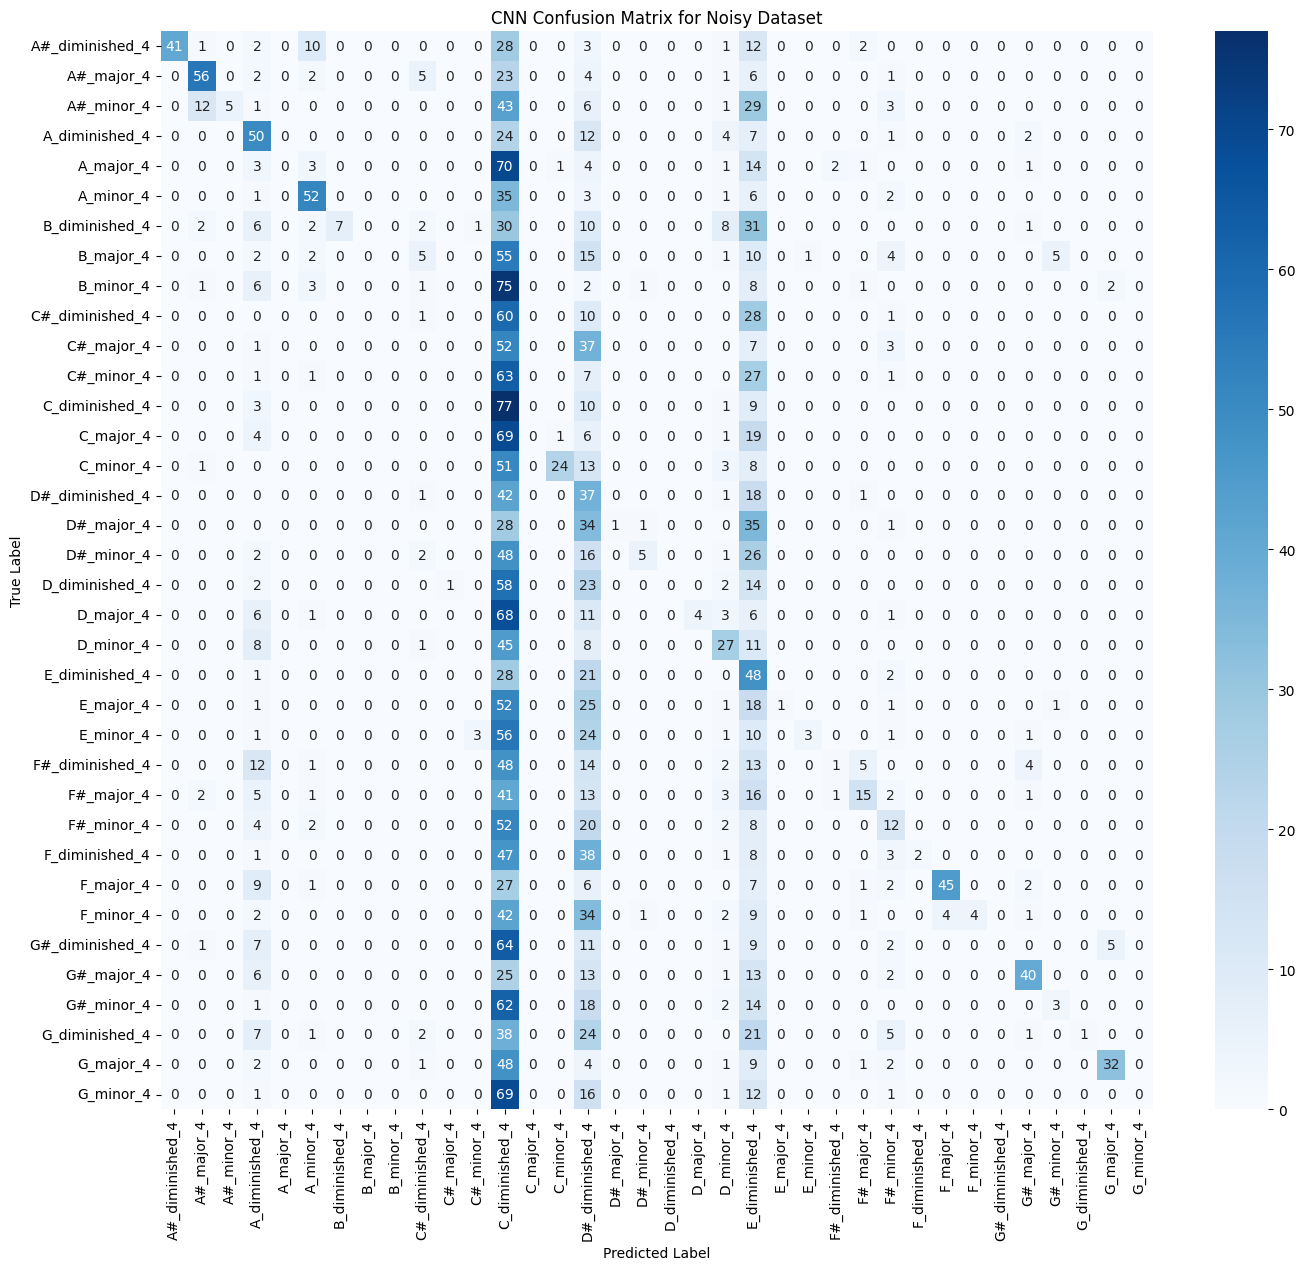

CNN Test Accuracy on Noisy Dataset: 0.165

CNN Classification Report for Noisy Dataset:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      0.41      0.58       100
     A#_major_4       0.74      0.56      0.64       100
     A#_minor_4       1.00      0.05      0.10       100
 A_diminished_4       0.31      0.50      0.38       100
      A_major_4       0.00      0.00      0.00       100
      A_minor_4       0.63      0.52      0.57       100
 B_diminished_4       1.00      0.07      0.13       100
      B_major_4       0.00      0.00      0.00       100
      B_minor_4       0.00      0.00      0.00       100
C#_diminished_4       0.05      0.01      0.02       100
     C#_major_4       0.00      0.00      0.00       100
     C#_minor_4       0.00      0.00      0.00       100
 C_diminished_4       0.04      0.77      0.08       100
      C_major_4       0.00      0.00      0.00       100
      C_minor_4       0.92      0.24      0.38       10

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Fit label encoder on clean labels (all classes the model was trained on)
noisy_label_encoder = LabelEncoder()
noisy_label_encoder.fit(noisy_labels)
num_classes = len(noisy_label_encoder.classes_)

# Encode noisy labels using the clean label encoder
noisy_encoded_labels = noisy_label_encoder.transform(noisy_labels)
noisy_categorical_labels = to_categorical(noisy_encoded_labels, num_classes=num_classes)

# Reshape noisy_features to add a channel dimension
noisy_features_reshaped = np.expand_dims(noisy_features, axis=-1)

# Get predictions for the noisy test set
noisy_predictions = clean_loaded_model.predict(noisy_features_reshaped)
predicted_noisy_classes = np.argmax(noisy_predictions, axis=1)
actual_noisy_classes = np.argmax(noisy_categorical_labels, axis=1)

# Get class labels from the label encoder
class_labels = noisy_label_encoder.classes_

# Compute the confusion matrix
cm_noisy = confusion_matrix(actual_noisy_classes, predicted_noisy_classes)

# Plot the confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix for Noisy Dataset')
plt.show()

# Generate classification report
accuracy_noisy = accuracy_score(actual_noisy_classes, predicted_noisy_classes)
print(f"CNN Test Accuracy on Noisy Dataset: {accuracy_noisy}")

report_noisy = classification_report(actual_noisy_classes, predicted_noisy_classes, target_names=class_labels)
print("\nCNN Classification Report for Noisy Dataset:\n", report_noisy)